# K-mer occurrence spectra

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

In [41]:
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

c_darkblue = CB_color_cycle[0]
c_darkgreen = CB_color_cycle[2]
c_darkpurple = CB_color_cycle[4]
c_darkred = CB_color_cycle[1]

In [42]:
XSMALL_SIZE = 10
SMALL_SIZE = 11
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Number of distinct k-mers

In [43]:
fly = pd.read_csv("fly.unmasked.kmer.stats", sep = "\t")
fly.head()

,kmer-size,distinct-kmer-count
0,11,2097094
1,13,27828199
2,15,89301151
3,17,113312955
4,19,118293273


In [44]:
fly_masked = pd.read_csv("fly.masked.kmer.stats", sep = "\t")
fly_masked.head()

,kmer-size,distinct-kmer-count
0,11,2097144
1,13,28721983
2,15,93672392
3,17,117204311
4,19,121306002


In [45]:
max_kmer_count = []
for k in fly_masked["kmer-size"]:
    max_kmer_count.append(4**k)

In [46]:
max_kmer_count

[4194304,
 67108864,
 1073741824,
 17179869184,
 274877906944,
 4398046511104,
 70368744177664]

In [47]:
simulated = pd.read_csv("simulated.kmer.stats", sep = "\t")
simulated.head()

,kmer-size,distinct-kmer-count
0,11,2097152
1,13,33075052
2,15,125166677
3,17,141345845
4,19,142448372


In [48]:
upper_bound = simulated.copy()
L = 142522964

max_count = []
for index, row in upper_bound.iterrows():
    max_count.append(min([round(4**row['kmer-size']/2), L - row["kmer-size"] + 1]))
    
upper_bound["max-count"] = max_count
upper_bound

,kmer-size,distinct-kmer-count,max-count
0,11,2097152,2097152
1,13,33075052,33554432
2,15,125166677,142522950
3,17,141345845,142522948
4,19,142448372,142522946
5,21,142518221,142522944
6,23,142522620,142522942


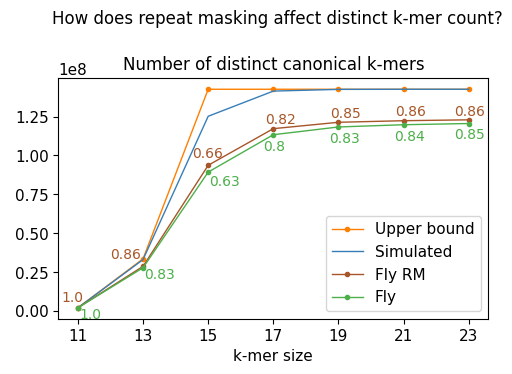

In [49]:
def plot_distinct(ax):
    ax.plot(upper_bound["kmer-size"], upper_bound["max-count"], linewidth = 1, label = "Upper bound", color = c_darkred, marker = ".")
    ax.plot(simulated["kmer-size"], simulated["distinct-kmer-count"], linewidth = 1, label = "Simulated", color = c_darkblue)
    ax.plot(fly_masked["kmer-size"], fly_masked["distinct-kmer-count"], linewidth = 1, label = "Fly RM", color = c_darkpurple, marker = ".")
    ax.plot(fly["kmer-size"], fly["distinct-kmer-count"], linewidth = 1, label = "Fly", color = c_darkgreen, marker = ".")

    
    text_color = c_darkgreen
    inf_cont_labels = np.round(fly["distinct-kmer-count"] / upper_bound["max-count"], 2)
    for x, y, text in zip(fly["kmer-size"], fly["distinct-kmer-count"], inf_cont_labels):
        if x > 22:
            ax.text(x-0.45, y-1e7, text, size = XSMALL_SIZE, color = text_color)
        elif x > 16:
            ax.text(x-0.3, y-1e7, text, size = XSMALL_SIZE, color = text_color)
            #ax1.text(x-0.25, y+0.6e7, text, size = XSMALL_SIZE, color = c_darkpurple)
        elif x > 14:
            ax.text(x+0.04, y-0.9e7, text, size = XSMALL_SIZE, color = text_color)
        else:
            ax.text(x+0.04, y-0.7e7, text, size = XSMALL_SIZE, color = text_color)

    text_color = c_darkpurple
    inf_cont_labels = np.round(fly_masked["distinct-kmer-count"] / upper_bound["max-count"], 2)
    for x, y, text in zip(fly_masked["kmer-size"], fly_masked["distinct-kmer-count"], inf_cont_labels):
        if x > 22:
            ax.text(x-0.45, y+0.3e7, text, size = XSMALL_SIZE, color = text_color)
        elif x > 16:
            ax.text(x-0.25, y+0.3e7, text, size = XSMALL_SIZE, color = text_color)
        elif x > 14:
            ax.text(x-0.5, y+0.5e7, text, size = XSMALL_SIZE, color = text_color)
        elif x > 12:
            ax.text(x-1, y+0.5e7, text, size = XSMALL_SIZE, color = text_color)
        else:
            ax.text(x-0.5, y+0.4e7, text, size = XSMALL_SIZE, color = text_color)
        
    ax.set_xticks(fly["kmer-size"])
    ax.set_xlabel("k-mer size")
    #ax.set_ylabel("Distinct k-mer count")
    ax.set_title("Number of distinct canonical k-mers")
    ax.legend(loc = "lower right")

fig, ax1 = plt.subplots(1)
fig.set_figheight(3.8)
fig.set_figwidth(5)

plot_distinct(ax1)

fig.suptitle("        How does repeat masking affect distinct k-mer count?")
fig.tight_layout()
fig.savefig('140Mb_distinct_RM.svg', dpi = 250)

## Compare 11-mer occurrence counts

Fly genome vs simulated genome of the same size

In [50]:
def read_occ_table(path):
    df = pd.read_csv(path, sep = "\t", header = None)
    df.columns = ["count", "occurrences"]
    df["frequency"] = df["count"] / np.sum(df["count"])
    if (abs(1 - np.sum(df["frequency"])) > 0.05):
        print("Incorrect frequency")
    return df

### Fly genome

In [51]:
fly_occ = read_occ_table("fly.11mer.tsv")
fly_occ.head()

,count,occurrences,frequency
0,329,1,0.000157
1,895,2,0.000427
2,1929,3,0.000920
3,3453,4,0.001647
4,5152,5,0.002457


### Sampled bases

In [52]:
sim_occ = read_occ_table("simulated.11mer.tsv")
sim_occ.head()

,count,occurrences,frequency
0,2,31,9.536743e-07
1,3,33,1.430511e-06
2,1,34,4.768372e-07
3,8,35,3.814697e-06
4,19,36,9.059906e-06


In [53]:
np.sum(sim_occ["count"] * sim_occ["occurrences"])

142522964

### Sampled k-mers

simulate a binomial distribution

In [54]:
rand_sample = np.random.randint(low=0.0, high=4**11/2, size=np.sum(sim_occ["count"] * sim_occ["occurrences"]))
rand_sample

array([ 581107, 2047959, 1447146, ...,  376591, 1669195, 2077787])

In [55]:
kmer, kmer_count = np.unique(rand_sample, return_counts = True)

occurrences, count = np.unique(kmer_count, return_counts = True)
data = {'count': count,
        'occurrences': occurrences}

rand_occ = pd.DataFrame(data)

In [56]:
#del kmer, rand_sample, kmer_count
rand_occ["frequency"] = rand_occ["count"] / np.sum(rand_occ["count"])
rand_occ.sort_values(by=['occurrences'], inplace = True)
rand_occ.head()

,count,occurrences,frequency
0,4,33,0.000002
1,6,35,0.000003
2,25,36,0.000012
3,38,37,0.000018
4,55,38,0.000026


### General functions 

K-mer abundance is the number of times a distinct k-mer appears in a dataset.

In [57]:
def kmer_stats(df):
    print("No of distinct k-mers\t" + str(np.sum(df["count"])))
    print("Mode of k-mer abundance\t" + str(df["occurrences"][np.argmax(df["count"])]))
    
    print("\tThere are " + str(np.max(df["count"])) + " k-mers that appear " + str(df["occurrences"][np.argmax(df["count"])]) + " times")
    print("\t" + str(np.round(np.max(df["frequency"]) * 100, 2)) + "% of all distinct k-mers appear " + str(df["occurrences"][np.argmax(df["count"])]) + " times")
    print()
    print("K-mer counter stats")
    print("\tmin\t" + str(np.min(df["occurrences"])))
    weighted_sum = np.sum(df["occurrences"] * df["count"])
    mean_kmer_count = np.round(weighted_sum / np.sum(df["count"]))
    print("\tmean\t" + str(mean_kmer_count))
    print("\tmax\t" + str(np.max(df["occurrences"])))

In [58]:
kmer_stats(fly_occ)

No of distinct k-mers	2097094
Mode of k-mer abundance	24
	There are 32555 k-mers that appear 24 times
	1.55% of all distinct k-mers appear 24 times

K-mer counter stats
	min	1
	mean	68.0
	max	64000


In [59]:
kmer_stats(sim_occ)

No of distinct k-mers	2097152
Mode of k-mer abundance	67
	There are 101216 k-mers that appear 67 times
	4.83% of all distinct k-mers appear 67 times

K-mer counter stats
	min	31
	mean	68.0
	max	109


In [60]:
kmer_stats(rand_occ)

No of distinct k-mers	2097152
Mode of k-mer abundance	67
	There are 102051 k-mers that appear 67 times
	4.87% of all distinct k-mers appear 67 times

K-mer counter stats
	min	33
	mean	68.0
	max	111


In [61]:
def plot_abundance(ax, df, abundance_thresh, max_freq, name, colorname):
    df_low_abundance = df.loc[df['occurrences'] <= abundance_thresh]
    ax.bar(df_low_abundance["occurrences"], df_low_abundance["frequency"], width = 1.0, color = colorname, label = name, alpha=0.75)
    #ax.legend(loc = "upper right")
    ax.set_xlim([-abundance_thresh*0.01, abundance_thresh])
    ax.set_ylim(0, max_freq)
    #ax.set_title(name, fontsize = MEDIUM_SIZE)

In [62]:
np.sum(fly_occ["count"] * fly_occ["occurrences"])

142522974

In [63]:
np.sum(sim_occ["count"] * sim_occ["occurrences"])

142522964

Among all represented k-mers, most appear between 1 and 100 times. The following plots do not show the few k-mers that appear very often. 

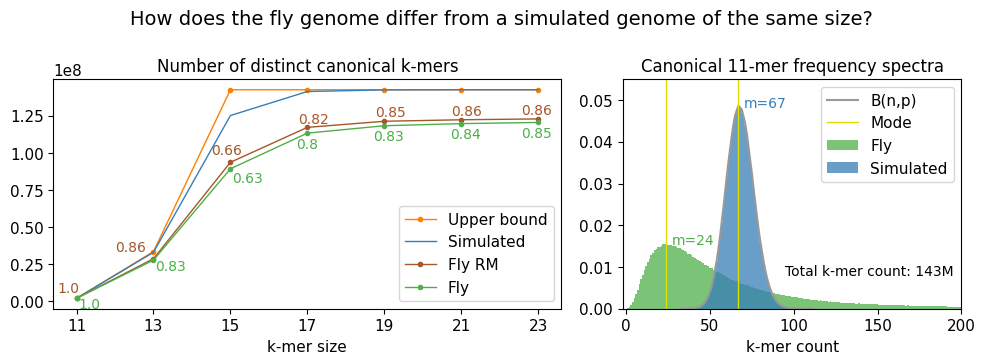

In [64]:
stacked = False
if stacked:
    fig, (ax1, ax2) = plt.subplots(2, height_ratios=[7, 6])
    fig.set_figheight(6.5)
    fig.set_figwidth(6)
    fig.suptitle("How does the fly genome differ from a simulated genome of the same size?")
else:
    fig, (ax1, ax2) = plt.subplots(ncols = 2, width_ratios=[12, 8])
    fig.set_figheight(3.7)
    fig.set_figwidth(10)
    fig.suptitle("How does the fly genome differ from a simulated genome of the same size?", size = BIGGER_SIZE)

plot_distinct(ax1)

# plot binomial trial
ax2.plot(rand_occ["occurrences"], rand_occ["frequency"], color = CB_color_cycle[6], label = "B(n,p)")

plot_abundance(ax2, fly_occ, 200, 0.055, "Fly", c_darkgreen)
plot_abundance(ax2, sim_occ, 200, 0.055, "Simulated", c_darkblue)

ab_mode = fly_occ["occurrences"][np.argmax(fly_occ["count"])]
ax2.axvline(ab_mode, linewidth = 1, label = "Mode", color = CB_color_cycle[8])
ax2.text(ab_mode + 3, fly_occ["frequency"][np.argmax(fly_occ["count"])], "m=" + str(ab_mode), size = XSMALL_SIZE, color = c_darkgreen)

ab_mode = sim_occ["occurrences"][np.argmax(sim_occ["count"])]
ax2.axvline(ab_mode, linewidth = 1, color = CB_color_cycle[8])
ax2.text(ab_mode + 3, sim_occ["frequency"][np.argmax(sim_occ["count"])], "m=" + str(ab_mode), size = XSMALL_SIZE, color = c_darkblue)

#ab_mode = rand_occ["occurrences"][np.argmax(rand_occ["count"])]
#ax2.axvline(ab_mode, linewidth = 1, color = CB_color_cycle[4], alpha = 0.75)

ax2.text(95, 0.008, "Total k-mer count: 143M", size = XSMALL_SIZE)
#ax2.text(95, 0.004, "E(x)=" + str(round(np.sum(sim_occ["count"] * sim_occ["occurrences"]) / np.sum(sim_occ["count"]))), size = XSMALL_SIZE)

#ax2.text(110, 0.005, "Max k-mer count: " + str(np.max(fly_occ["occurrences"])), size = XSMALL_SIZE, color = c_darkgreen)
#ax2.text(110, 0.02, "Total k-mer count: " + str(np.sum(rand_occ["count"] * rand_occ["occurrences"])), size = XSMALL_SIZE, color = CB_color_cycle[6])

ax2.set_title("Canonical 11-mer frequency spectra")

ax2.legend(loc = "upper right")
ax2.set_xlabel("k-mer count")

#handles, labels = ax1.get_legend_handles_labels()
#fig.legend(handles, labels, bbox_to_anchor=(0.935,0.75))

fig.tight_layout()
fig.savefig('140Mb_spectra_RM.svg', dpi = 200)

In [26]:
ab_mean = np.sum(sim_occ["count"] * sim_occ["occurrences"]) / np.sum(sim_occ["count"])
round(ab_mean)

68

In [27]:
ab_mean = np.sum(fly_occ["count"] * fly_occ["occurrences"]) / np.sum(fly_occ["count"])
round(ab_mean)

68

In [28]:
np.sum(sim_occ["count"] * sim_occ["occurrences"])

142522964

In [29]:
np.sum(sim_occ["occurrences"])

5498

In [30]:
sim_occ[sim_occ["frequency"] > 0.99*np.max(sim_occ["frequency"])]

,count,occurrences,frequency
35,101216,67,0.048264
36,100831,68,0.048080


In [31]:
fly

,kmer-size,distinct-kmer-count
0,11,2097094
1,13,27828199
2,15,89301151
3,17,113312955
4,19,118293273
5,21,119732435
6,23,120509016


In [32]:
simulated

,kmer-size,distinct-kmer-count
0,11,2097152
1,13,33075052
2,15,125166677
3,17,141345845
4,19,142448372
5,21,142518221
6,23,142522620


In [33]:
upper_bound

,kmer-size,distinct-kmer-count,max-count
0,11,2097152,2097152
1,13,33075052,33554432
2,15,125166677,142522950
3,17,141345845,142522948
4,19,142448372,142522946
5,21,142518221,142522944
6,23,142522620,142522942


## Compare fly k-mer spectra

for 11 <= k <= 21

In [34]:
fly = read_occ_table("fly.21mer.tsv")
fly.head()

,count,occurrences,frequency
0,115845784,1,0.967539
1,1894038,2,0.015819
2,575980,3,0.004811
3,297125,4,0.002482
4,180731,5,0.001509


In [35]:
kmer_stats(fly)

No of distinct k-mers	119732417
Mode of k-mer abundance	1
	There are 115845784 k-mers that appear 1 times
	96.75% of all distinct k-mers appear 1 times

K-mer counter stats
	min	1
	mean	1.0
	max	11558


In [36]:
df_high_abundance = fly.loc[fly['occurrences'] >= 50]
df_high_abundance

,count,occurrences,frequency
49,2506,50,2.093000e-05
50,2311,51,1.930137e-05
51,2207,52,1.843277e-05
52,2146,53,1.792330e-05
53,2288,54,1.910928e-05
...,...,...,...
848,1,9407,8.351957e-09
849,1,9508,8.351957e-09
850,1,9560,8.351957e-09
851,1,11402,8.351957e-09


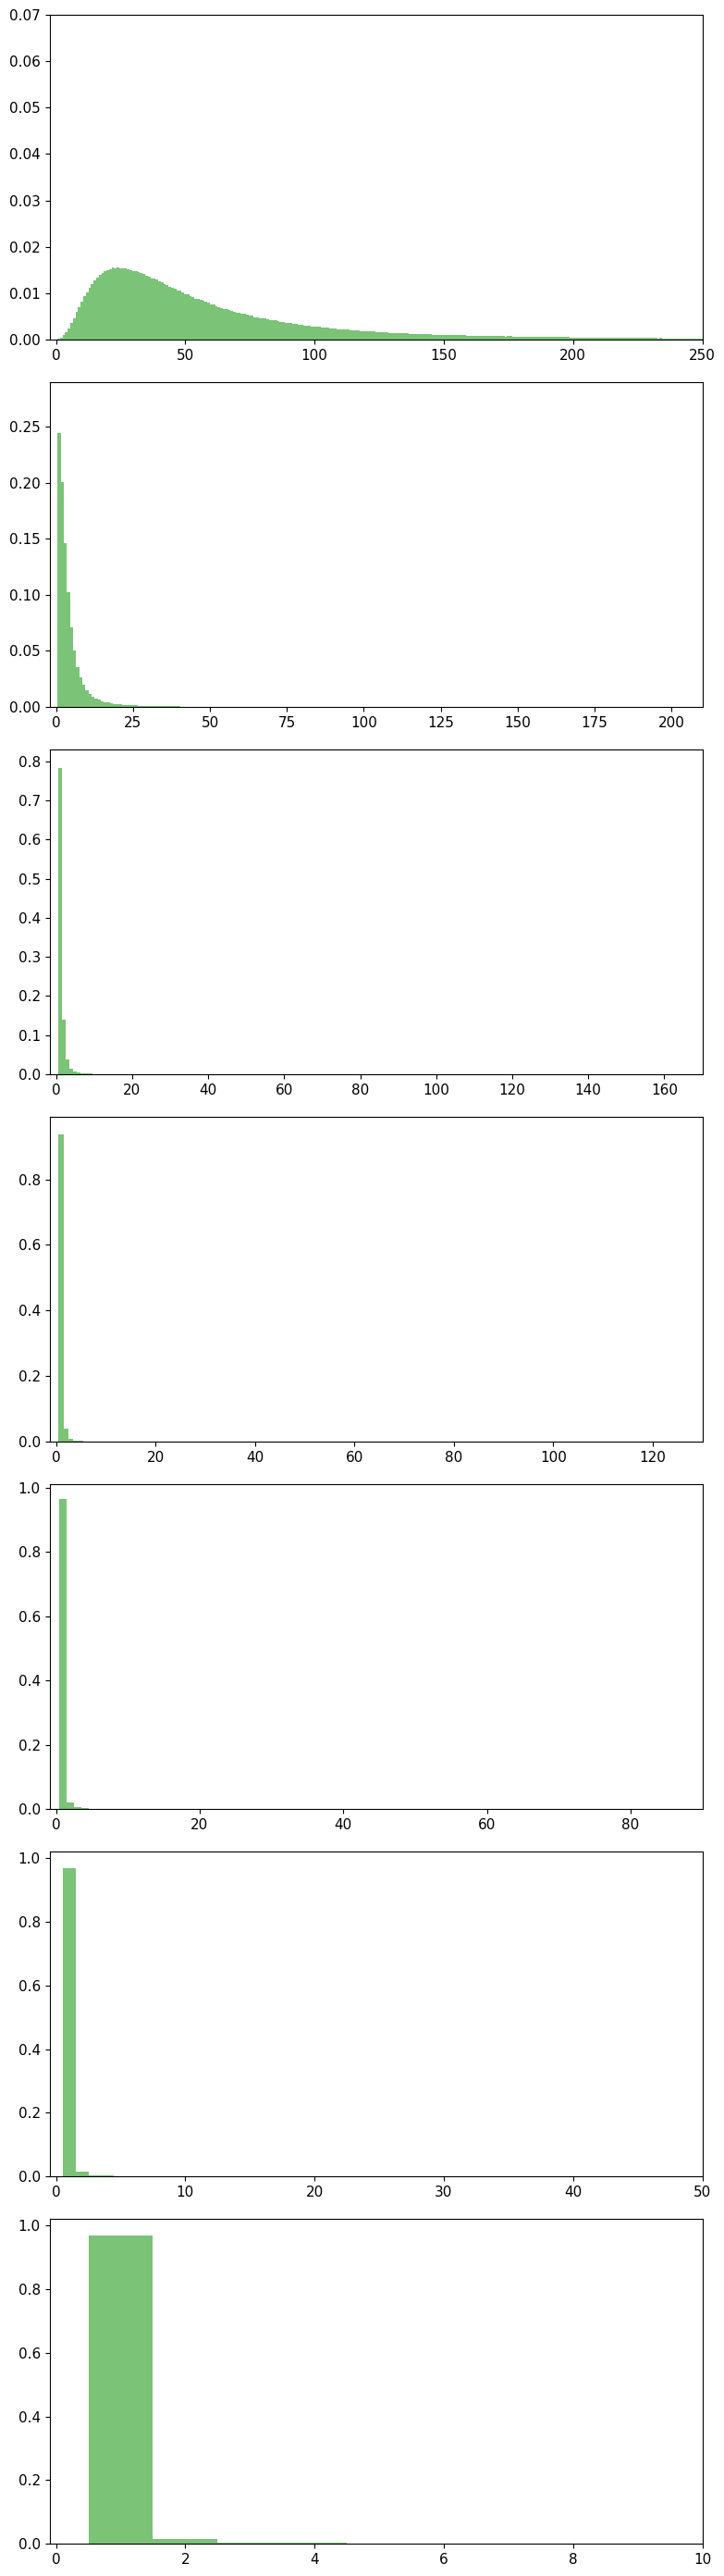

In [37]:
fig, axs = plt.subplots(7)
#fig.suptitle("Fly k-mer frequency spectra")
fig.set_figheight(4*7)
fig.set_figwidth(8)

i = 0
for k in [11, 13, 15, 17, 19, 21, 23]:
    fly = read_occ_table("fly."+ str(k) +"mer.tsv")
    plot_abundance(axs[i], fly, 250 - i*40, np.max(np.round(fly["frequency"], 2) + 0.05), str(k) + "-mer", c_darkgreen)
    i+=1
fig.tight_layout()